# Task 3 - Forest Cover Type Classification

The goal of this project is to predict the type of forest cover based on different cartographic and environmental features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV

In [2]:
df = pd.read_csv(
    "data/covtype.data",
    header=None
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (581012, 55)


,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


The dataset is provided as a raw data file without column names.

It contains information about forest areas, including elevation, slope, distances to different locations, hillshade values, wilderness areas, and soil types.

The last column represents the forest cover type.

## Add Column Names

The original dataset does not include column names, so they are added based on the dataset description.

There are 54 input features and one target column called `Cover_Type`.

The features include numerical measurements, wilderness area indicators, and soil type indicators.

In [3]:
numeric_features = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

wilderness_features = [
    f"Wilderness_Area_{i}"
    for i in range(1, 5)
]

soil_features = [
    f"Soil_Type_{i}"
    for i in range(1, 41)
]

columns = (
    numeric_features
    + wilderness_features
    + soil_features
    + ["Cover_Type"]
)

df.columns = columns

print("Number of columns:", len(df.columns))

df.head()

Number of columns: 55


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Soil_Type_40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Basic Data Inspection

Before cleaning the data, I will check the dataset structure, data types, missing values, and duplicate rows.

I will also check the distribution of the target variable to see how the seven forest cover types are distributed.

In [4]:
print("Dataset shape:", df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["Cover_Type"].value_counts().sort_index())

Dataset shape: (581012, 55)

Data types:
int64    55
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0

Target distribution:
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


## Data Cleaning

The dataset does not contain missing values or duplicate rows.

I will still check the feature ranges and the target values to make sure there are no invalid values that could affect the classification model.

In [5]:
print("Minimum values:")
print(df.min().head(10))

print("\nMaximum values:")
print(df.max().head(10))

print("\nTarget values:")
print(sorted(df["Cover_Type"].unique()))

Minimum values:
Elevation                             1859
Aspect                                   0
Slope                                    0
Horizontal_Distance_To_Hydrology         0
Vertical_Distance_To_Hydrology        -173
Horizontal_Distance_To_Roadways          0
Hillshade_9am                            0
Hillshade_Noon                           0
Hillshade_3pm                            0
Horizontal_Distance_To_Fire_Points       0
dtype: int64

Maximum values:
Elevation                             3858
Aspect                                 360
Slope                                   66
Horizontal_Distance_To_Hydrology      1397
Vertical_Distance_To_Hydrology         601
Horizontal_Distance_To_Roadways       7117
Hillshade_9am                          254
Hillshade_Noon                         254
Hillshade_3pm                          254
Horizontal_Distance_To_Fire_Points    7173
dtype: int64

Target values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5),

### Check Target Values

The target variable represents the forest cover type.

The dataset should contain seven cover types, represented by values from 1 to 7.

In [6]:
invalid_target = df[
    ~df["Cover_Type"].isin(range(1, 8))
]

print("Invalid target values:", len(invalid_target))

Invalid target values: 0


## Exploratory Data Analysis

After checking the data quality, I will explore the main features and the distribution of the forest cover types.

Since the dataset contains seven different cover types, I will first visualize how many samples belong to each class.

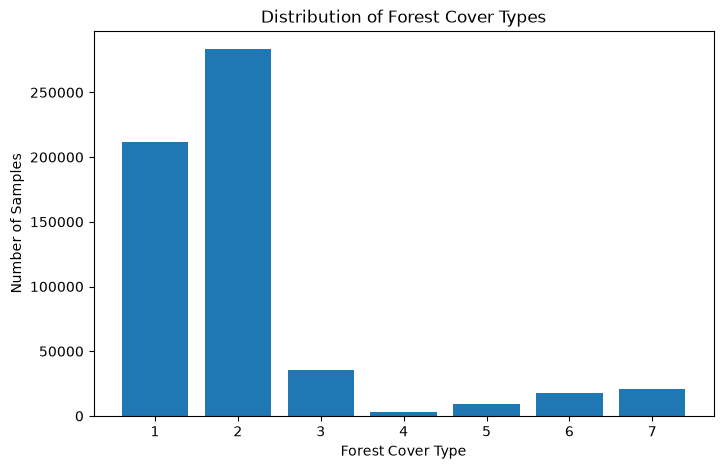

In [7]:
cover_counts = df["Cover_Type"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cover_counts.index.astype(str),
    cover_counts.values
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Distribution of Forest Cover Types")

plt.show()

### Class Imbalance

The target variable is not evenly distributed across the seven forest cover types.

Cover Types 1 and 2 contain most of the samples, while Cover Type 4 has a much smaller number of samples.

This class imbalance should be considered when evaluating the classification models, so accuracy will not be used as the only evaluation metric.

In [8]:
class_distribution = pd.DataFrame({
    "Count": cover_counts,
    "Percentage": (cover_counts / len(df) * 100).round(2)
})

class_distribution.index.name = "Cover_Type"

class_distribution

,Count,Percentage
Cover_Type,,
1,211840,36.46
2,283301,48.76
3,35754,6.15
4,2747,0.47
5,9493,1.63
6,17367,2.99
7,20510,3.53


### Elevation by Cover Type

Elevation is one of the main cartographic features in the dataset.

I will compare the elevation distribution across the seven forest cover types to see whether different cover types tend to occur at different elevations.

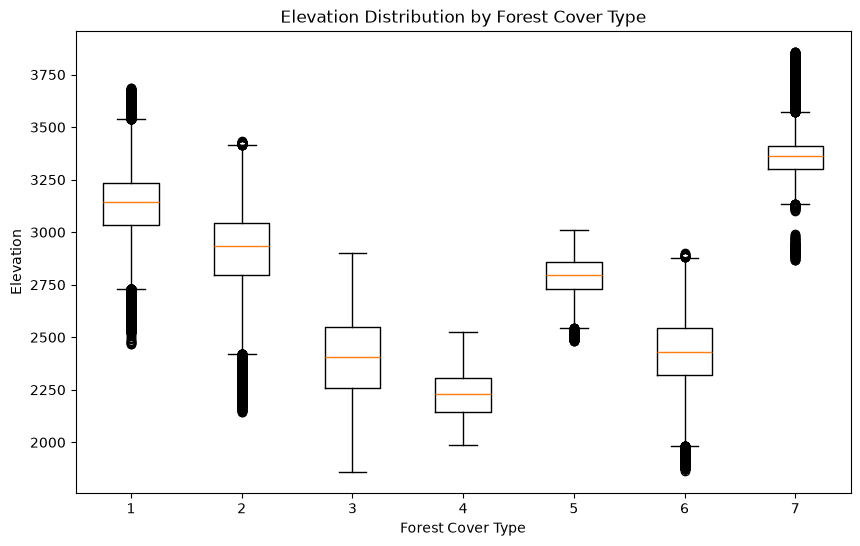

In [9]:
elevation_by_cover = [
    df.loc[df["Cover_Type"] == cover_type, "Elevation"]
    for cover_type in sorted(df["Cover_Type"].unique())
]

plt.figure(figsize=(10, 6))

plt.boxplot(
    elevation_by_cover,
    tick_labels=sorted(df["Cover_Type"].unique())
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Elevation")
plt.title("Elevation Distribution by Forest Cover Type")

plt.show()

The boxplot shows that elevation varies across the different forest cover types.

Cover Type 7 generally appears at higher elevations, while Cover Type 4 appears at lower elevations. However, there is some overlap between several cover types, which means that elevation alone is not enough to accurately predict the forest cover type.

This suggests that using multiple features together should provide better classification results.

In [10]:
mean_by_cover = df.groupby("Cover_Type")[numeric_features].mean()

mean_by_cover.round(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
Cover_Type,,,,,,,,,,
1,3128.64,156.14,13.13,270.56,42.16,2614.83,212.00,223.43,143.88,2009.25
2,2920.94,152.06,13.55,279.92,45.88,2429.53,213.84,225.33,142.98,2168.15
3,2394.51,176.37,20.77,210.28,62.45,943.94,201.92,215.83,140.37,910.96
4,2223.94,137.14,18.53,106.93,41.19,914.20,228.35,217.00,111.39,859.12
5,2787.42,139.28,16.64,212.35,50.61,1349.77,223.47,219.04,121.92,1577.72
6,2419.18,180.54,19.05,159.85,45.44,1037.17,192.84,209.83,148.28,1055.35
7,3361.93,153.24,14.26,356.99,69.47,2738.25,216.97,221.75,134.93,2070.03


### Feature Comparison Across Cover Types

The mean values show that several features differ across the forest cover types.

For example, elevation and distance-related features show noticeable differences between some classes. These differences suggest that multiple environmental and cartographic features can help distinguish between the cover types.

However, the mean values only show general differences between classes. The classification model uses all features together to make predictions for individual samples.

## Prepare Data for Classification

The dataset is now ready for modeling.

I will separate the input features from the target variable and split the data into training and testing sets.

Since the target classes are imbalanced, I will use a stratified split to keep a similar class distribution in both sets.

In [11]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (464809, 54)
Testing set: (116203, 54)


## Train a Random Forest Classifier

I will start with a Random Forest classifier as the baseline model.

Random Forest is suitable for this task because it can handle many numerical and binary features and can model non-linear relationships between the features and the forest cover types.

No feature scaling is required because Random Forest is a tree-based model.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Evaluate the Random Forest

After training the model, I will evaluate its performance on the testing set.

I will use accuracy together with precision, recall, and F1-score for each forest cover type.

The classification report is especially important because the target classes are imbalanced.

In [13]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9542

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.94      0.95     42368
           2       0.95      0.97      0.96     56661
           3       0.94      0.96      0.95      7151
           4       0.91      0.85      0.88       549
           5       0.95      0.78      0.86      1899
           6       0.93      0.89      0.91      3473
           7       0.97      0.95      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.95      0.91      0.92    116203
weighted avg       0.95      0.95      0.95    116203



## Confusion Matrix

The classification report shows that the Random Forest performs well overall, but some classes have lower recall than others.

The confusion matrix will help identify which forest cover types are most often confused with each other.

<Figure size 900x700 with 0 Axes>

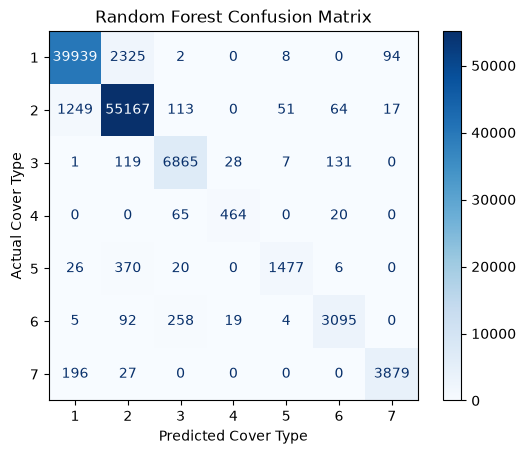

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(y.unique())
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Cover Type")
plt.ylabel("Actual Cover Type")

plt.show()

## Feature Importance

Random Forest provides feature importance scores that can be used to understand which features contributed most to the classification.

I will select the top 15 features and visualize their importance scores.

In [15]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(15)

top_features

,Feature,Importance
0,Elevation,0.243272
5,Horizontal_Distance_To_Roadways,0.118428
9,Horizontal_Distance_To_Fire_Points,0.110580
3,Horizontal_Distance_To_Hydrology,0.060340
4,Vertical_Distance_To_Hydrology,0.057840
1,Aspect,0.047578
7,Hillshade_Noon,0.042614
6,Hillshade_9am,0.041402
8,Hillshade_3pm,0.040771
2,Slope,0.032846


### Top 15 Important Features

The feature importance scores show that Elevation is the most important feature in the Random Forest model.

Distance-related features also have relatively high importance, while some soil and wilderness features have lower importance.

I will visualize the top 15 features to make these differences easier to compare.

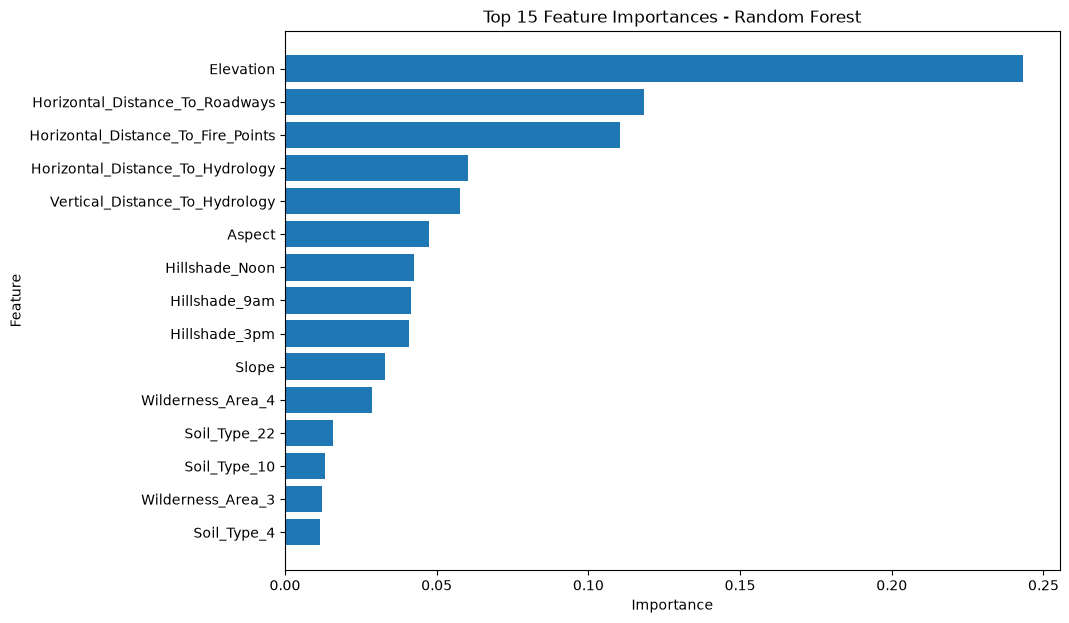

In [16]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.show()

## Bonus: XGBoost Comparison

As an additional experiment, I will compare the Random Forest model with an XGBoost classifier.

## Train an XGBoost Classifier

I will train an XGBoost classifier as a second tree-based model.

The model will use the same training and testing data as the Random Forest so that the two models can be compared fairly.

I will start with a simple baseline configuration without extensive hyperparameter tuning.

In [17]:
y_train_xgb = y_train - 1
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train_xgb)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Evaluate XGBoost

After training the XGBoost model, I will evaluate its performance on the testing set using the same metrics used for Random Forest.

The predicted labels are converted back to the original cover type values from 1 to 7 so they can be compared directly with the Random Forest results.

In [18]:
y_pred_xgb = xgb_model.predict(X_test) + 1

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8093

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.78      0.79     42368
           2       0.81      0.86      0.83     56661
           3       0.79      0.86      0.83      7151
           4       0.83      0.82      0.82       549
           5       0.88      0.35      0.50      1899
           6       0.74      0.52      0.61      3473
           7       0.90      0.82      0.86      4102

    accuracy                           0.81    116203
   macro avg       0.82      0.72      0.75    116203
weighted avg       0.81      0.81      0.81    116203



## Compare Random Forest and XGBoost

The Random Forest model achieved higher performance than the XGBoost model in this experiment.

I will compare their main evaluation metrics to clearly see the difference in performance.

In [19]:
rf_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

xgb_report = classification_report(
    y_test,
    y_pred_xgb,
    output_dict=True
)

model_comparison = pd.DataFrame({
    "Random Forest": [
        accuracy,
        rf_report["macro avg"]["precision"],
        rf_report["macro avg"]["recall"],
        rf_report["macro avg"]["f1-score"]
    ],
    "XGBoost": [
        xgb_accuracy,
        xgb_report["macro avg"]["precision"],
        xgb_report["macro avg"]["recall"],
        xgb_report["macro avg"]["f1-score"]
    ]
}, index=[
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1-Score"
])

model_comparison.round(4)

,Random Forest,XGBoost
Accuracy,0.9542,0.8093
Macro Precision,0.9457,0.8211
Macro Recall,0.9052,0.7166
Macro F1-Score,0.9238,0.7497


### Comparison Results

The Random Forest model performed better than XGBoost in this experiment.

Random Forest achieved an accuracy of 95.42%, compared with 80.93% for XGBoost. It also achieved higher macro precision, macro recall, and macro F1-score.

The difference is especially clear in macro recall and macro F1-score, which are important because the dataset is imbalanced. XGBoost had more difficulty identifying some of the less common forest cover types, especially Cover Types 5 and 6.

Based on these results, Random Forest is the better-performing model for this dataset in the current experiment.

## Hyperparameter Tuning

Since Random Forest achieved better results than XGBoost in the previous experiment, I will try to improve its performance by tuning some of its hyperparameters.

RandomizedSearchCV will be used to test a limited number of parameter combinations instead of trying every possible combination.

Because the dataset is large, a smaller sample of the training data will be used for tuning to reduce the training time.

In [20]:
# sample of the training data for tuning
tuning_sample_size = 100000

X_train_tune = X_train.sample(
    n=tuning_sample_size,
    random_state=42
)

y_train_tune = y_train.loc[X_train_tune.index]

print("Tuning sample:", X_train_tune.shape)

Tuning sample: (100000, 54)


### Define Hyperparameter Search

I will tune a few important Random Forest parameters, including the number of trees, tree depth, minimum samples required for splitting, and the number of features considered at each split.

The search will test a limited number of combinations to keep the training time reasonable.

In [21]:
rf_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 20, 30],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=6,
    cv=3,
    scoring="f1_macro",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Hyperparameter search setup completed.")

Hyperparameter search setup completed.


In [22]:
rf_tuning.fit(
    X_train_tune,
    y_train_tune
)

print("Hyperparameter tuning completed.")
print("Best parameters:")
print(rf_tuning.best_params_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Hyperparameter tuning completed.
Best parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}


### Train the Tuned Random Forest

The hyperparameter search found the best parameter combination based on macro F1-score.

I will now train a new Random Forest model using these parameters and evaluate it on the original testing set.

In [23]:
tuned_rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=30,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

tuned_rf_model.fit(X_train, y_train)

print("Tuned Random Forest model trained successfully.")

Tuned Random Forest model trained successfully.


## Evaluate the Tuned Random Forest

The tuned Random Forest will now be evaluated on the same testing set used for the baseline model.

I will compare accuracy, macro precision, macro recall, and macro F1-score to see whether tuning improved the model's performance.

In [24]:
y_pred_tuned = tuned_rf_model.predict(X_test)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_report = classification_report(
    y_test,
    y_pred_tuned,
    output_dict=True
)

print("Tuned Random Forest Accuracy:", round(tuned_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Accuracy: 0.947

Classification Report:
              precision    recall  f1-score   support

           1       0.96      0.93      0.94     42368
           2       0.94      0.97      0.95     56661
           3       0.94      0.96      0.95      7151
           4       0.92      0.86      0.89       549
           5       0.96      0.71      0.81      1899
           6       0.93      0.89      0.91      3473
           7       0.97      0.94      0.96      4102

    accuracy                           0.95    116203
   macro avg       0.94      0.89      0.92    116203
weighted avg       0.95      0.95      0.95    116203



### Hyperparameter Tuning Results

The tuned Random Forest achieved an accuracy of 94.70%, which is slightly lower than the baseline Random Forest accuracy of 95.42%.

The tuned model also achieved slightly lower macro precision, macro recall, and macro F1-score than the baseline model. It also had lower recall for some of the less common cover types, especially Cover Type 5.

Therefore, the baseline Random Forest performed better on the testing set and will be selected as the final model for this project.

This experiment shows that hyperparameter tuning does not always improve model performance. The result depends on the dataset and the selected parameters.

## Save the Final Model

Based on the evaluation results, the baseline Random Forest performed better than the tuned model and XGBoost.

I will save the baseline Random Forest model so it can be reused later without training it again.

In [25]:
os.makedirs("artifacts", exist_ok=True)

joblib.dump(
    {
        "model": rf_model,
        "features": X_train.columns.tolist()
    },
    "artifacts/forest_cover_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
